In [14]:
# background remove
from rembg import remove
from PIL import Image
import io

In [15]:
# bit mask
import numpy as np
from skimage import measure

In [16]:
# visualize bitmask
import matplotlib.pyplot as plt

In [17]:
# bitmask to vector
import numpy as np
from PIL import Image
import tempfile
import os
import vtracer
from skimage import filters
from skimage.io import imread, imsave

In [18]:
# smooth and simplify vector
import numpy as np
from svgpathtools import svg2paths
from scipy.interpolate import splprep, splev
import svgwrite

In [23]:
# combined vectorize with smoothing
import numpy as np
import tempfile
import os
from PIL import Image
import vtracer
from svgpathtools import svg2paths
from scipy.interpolate import splprep, splev
import svgwrite

In [ ]:
# Remove background and convert to bitmask
# Load input image and remove background
input_path = 'test/images/test4.jpg'  # replace with your image path

img = Image.open(input_path).convert('RGBA')

img_bytes = io.BytesIO()
img.save(img_bytes, format='PNG')
img_bytes = img_bytes.getvalue()

output_bytes = remove(img_bytes)
output_img = Image.open(io.BytesIO(output_bytes)).convert('RGBA')

# --- STEP 2: Threshold the alpha channel ---
alpha = np.array(output_img.split()[-1])  # extract alpha channel
binary_mask = alpha > 0  # threshold: foreground = True, background = False

# --- STEP 3: Extract contours ---
# Find contours at a constant value of 0.5 (True/False boundary)
contours = measure.find_contours(binary_mask, level=0.5)

# --- Visualization ---
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_mask, cmap='gray')
ax[1].set_title('Thresholded Alpha Mask')
ax[1].axis('off')

ax[2].imshow(binary_mask, cmap='gray')
for contour in contours:
    # ax[2].plot(contour[:, 1], contour[:, 0], linewidth=.8, color='white')
    ax[2].fill(contour[:, 1], contour[:, 0], facecolor="white", edgecolor="white", linewidth=1)

ax[2].set_title('Vector Outlines (Contours)')
ax[2].axis('off')

plt.tight_layout()
plt.show()


In [19]:
# remove background
def remove_background(input_path):
    """
    Remove background from an image using rembg
    
    Args:
        input_path (str): Path to input image
        
    Returns:
        PIL.Image: Image with background removed (RGBA format)
    """
    # Load input image and convert to RGBA
    img = Image.open(input_path).convert('RGBA')
    
    # Convert to bytes for rembg processing
    img_bytes = io.BytesIO()
    img.save(img_bytes, format='PNG')
    img_bytes = img_bytes.getvalue()
    
    # Remove background
    output_bytes = remove(img_bytes)
    output_img = Image.open(io.BytesIO(output_bytes)).convert('RGBA')
    
    return img, output_img
# original_img, no_bg_img = remove_background('test/images/test4.jpg')

In [20]:
# bit mask
def create_bitmask_and_contours(rgba_image):
    """
    Create binary mask from RGBA image and extract contours
    
    Args:
        rgba_image (PIL.Image): RGBA image with transparent background
        
    Returns:
        tuple: (binary_mask, contours)
            - binary_mask (numpy.ndarray): Boolean array where True = foreground
            - contours (list): List of contour arrays from skimage.measure.find_contours
    """
    # Extract alpha channel and create binary mask
    alpha = np.array(rgba_image.split()[-1])  # extract alpha channel
    binary_mask = alpha > 0  # threshold: foreground = True, background = False
    
    # Extract contours at the True/False boundary
    contours = measure.find_contours(binary_mask, level=0.5)
    
    return binary_mask, contours

# Usage example:
# binary_mask, contours = create_bitmask_and_contours(no_bg_img)

In [21]:
# visualize
def visualize_results(original_img, binary_mask, contours):
    """
    Visualize the original image, binary mask, and contours
    
    Args:
        original_img (PIL.Image): Original input image
        binary_mask (numpy.ndarray): Binary mask array
        contours (list): List of contour arrays
    """
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot original image
    ax[0].imshow(original_img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    # Plot binary mask
    ax[1].imshow(binary_mask, cmap='gray')
    ax[1].set_title('Thresholded Alpha Mask')
    ax[1].axis('off')
    
    # Plot contours on binary mask
    ax[2].imshow(binary_mask, cmap='gray')
    for contour in contours:
        ax[2].fill(contour[:, 1], contour[:, 0], 
                  facecolor="white", edgecolor="white", linewidth=1)
    ax[2].set_title('Vector Outlines (Contours)')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage example:
# visualize_results(original_img, binary_mask, contours)


In [ ]:


def convert_to_vector(input_image,output_svg):
    # open image 
    img = Image.open(input_image)

    # convert to numpy array for inversion
    img_array = np.array(img)

    # invert colors using numpy - subtract from max value (255 for 8-bit)
    if img_array.dtype == np.uint8:
        inverted_array = 255 - img_array
    else:
        inverted_array = np.iinfo(img_array.dtype).max - img_array

    # convert back to PIL Image
    inverted_img = Image.fromarray(inverted_array)

    # save in temp file
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as temp_file:
        temp_png_path = temp_file.name
        inverted_img.save(temp_png_path)

    # send temp file to convert_image_to_svg_py
    vtracer.convert_image_to_svg_py(temp_png_path, output_svg, colormode='binary')

    # cleanup temp file
    os.unlink(temp_png_path)
# vectorize
# input_png = "test/images/output_example_2.png"  # Change this to your PNG file path
# output_svg = "test/images/inverted_output2.svg" 

# convert_to_vector(input_png,output_svg)

# using scikit image add the Savitzky–Golay Filter 
# save the output as inverted_output_savitzky_golay.svg

In [2]:
# v2 in memory

import numpy as np
from PIL import Image
import io
import vtracer

def convert_rgba_to_vector(rgba_image):
    """
    Convert RGBA PIL Image to in-memory SVG vector.
    
    Args:
        rgba_image: PIL Image object in RGBA format
        
    Returns:
        str: SVG content as string
    """
    # Ensure image is in RGBA format
    if rgba_image.mode != 'RGBA':
        rgba_image = rgba_image.convert('RGBA')
    
    # Convert to numpy array for inversion
    img_array = np.array(rgba_image)
    
    # Invert RGB channels only, keep alpha channel unchanged
    inverted_array = img_array.copy()
    if img_array.dtype == np.uint8:
        # Invert only RGB channels (first 3 channels), keep alpha (channel 3) unchanged
        inverted_array[:, :, :3] = 255 - img_array[:, :, :3]
    else:
        max_val = np.iinfo(img_array.dtype).max
        inverted_array[:, :, :3] = max_val - img_array[:, :, :3]
    
    # Convert back to PIL Image
    inverted_img = Image.fromarray(inverted_array, 'RGBA')
    
    # Create in-memory PNG buffer
    png_buffer = io.BytesIO()
    inverted_img.save(png_buffer, format='PNG')
    png_buffer.seek(0)
    
    # Create in-memory SVG buffer
    svg_buffer = io.BytesIO()
    
    # Convert PNG buffer to SVG buffer using vtracer
    vtracer.convert_raw_image_to_svg(
        png_buffer.getvalue(),  # PNG data as bytes
        svg_buffer,             # Output SVG buffer
        colormode='binary'
    )
    
    # Get SVG content as string
    svg_buffer.seek(0)
    svg_content = svg_buffer.getvalue().decode('utf-8')
    
    return svg_content



In [3]:
# Example usage:
rgba_img = Image.open("test/images/output_example_2.png").convert('RGBA')
svg_result = convert_rgba_to_vector(rgba_img)
print(svg_result)  # SVG content as string

C:\Users\oran\AppData\Local\Temp\ipykernel_12732\3343315987.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  inverted_img = Image.fromarray(inverted_array, 'RGBA')


TypeError: argument 'img_format': 'BytesIO' object cannot be converted to 'PyString'

In [ ]:


input_svg = "test/images/inverted_output.svg"
output_svg = "test/images/smoothed_output.svg"
canvas_size = (500, 500)  # canvas size in px

# Load SVG paths
paths, _ = svg2paths(input_svg)

# Use the first path
path = paths[0]

# Sample a reduced number of points from the path
num_sampled_points = 50
points = np.array([path.point(t) for t in np.linspace(0, 1, num_sampled_points)])
x = points.real
y = points.imag

# Smooth with spline
tck, _ = splprep([x, y], s=1)  # lower 's' for tighter fit
u_new = np.linspace(0, 1, 40)  # fewer output points for simplicity
x_smooth, y_smooth = splev(u_new, tck)
smooth_points = np.column_stack((x_smooth, y_smooth))

# Compute bounding box
min_x, min_y = np.min(smooth_points, axis=0)
max_x, max_y = np.max(smooth_points, axis=0)
path_width = max_x - min_x
path_height = max_y - min_y

# Compute translation to center
canvas_width, canvas_height = canvas_size
translate_x = (canvas_width - path_width) / 2 - min_x
translate_y = (canvas_height - path_height) / 2 - min_y
smooth_points_centered = [(x + translate_x, y + translate_y) for x, y in smooth_points]

# Construct path string, close path with 'Z'
d_str = f"M {smooth_points_centered[0][0]},{smooth_points_centered[0][1]} " + \
        " ".join(f"L {x},{y}" for x, y in smooth_points_centered[1:]) + " Z"

# Create SVG with closed black-filled path
dwg = svgwrite.Drawing(output_svg, size=canvas_size)
dwg.add(dwg.path(d=d_str, fill="black", stroke="none"))
dwg.save()


In [27]:
# combined vectorize with smoothing


def convert_to_smoothed_vector(input_image, output_svg, canvas_size=(500, 500), num_sampled_points=50, output_points=40, smoothing=1):
    """
    Convert an image to a smoothed vector SVG.
    
    Args:
        input_image (str): Path to input image file
        output_svg (str): Path for output SVG file
        canvas_size (tuple): Canvas size in pixels (width, height)
        num_sampled_points (int): Number of points to sample from original path
        output_points (int): Number of points in smoothed output
        smoothing (float): Smoothing parameter for spline (lower = tighter fit)
    """
    
    # Step 1: Convert image to vector
    # Open and invert image
    img = Image.open(input_image)
    img_array = np.array(img)
    
    # Invert colors
    if img_array.dtype == np.uint8:
        inverted_array = 255 - img_array
    else:
        inverted_array = np.iinfo(img_array.dtype).max - img_array
    
    inverted_img = Image.fromarray(inverted_array)
    
    # Save inverted image to temp file
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as temp_png:
        temp_png_path = temp_png.name
        inverted_img.save(temp_png_path)
    
    # Create intermediate SVG
    with tempfile.NamedTemporaryFile(suffix='.svg', delete=False) as temp_svg:
        temp_svg_path = temp_svg.name
    
    try:
        # Convert to SVG
        vtracer.convert_image_to_svg_py(temp_png_path, temp_svg_path, colormode='binary')
        
        # Step 2: Smooth the vector
        # Load SVG paths
        paths, *_ = svg2paths(temp_svg_path)
        
        if not paths:
            raise ValueError("No paths found in the generated SVG")
        
        # Use the first path
        path = paths[0]
        
        # Sample points from the path
        points = np.array([path.point(t) for t in np.linspace(0, 1, num_sampled_points)])
        x = points.real
        y = points.imag
        
        # Smooth with spline
        tck, _ = splprep([x, y], s=smoothing)
        u_new = np.linspace(0, 1, output_points)
        x_smooth, y_smooth = splev(u_new, tck)
        smooth_points = np.column_stack((x_smooth, y_smooth))
        
        # Compute bounding box and center on canvas
        min_x, min_y = np.min(smooth_points, axis=0)
        max_x, max_y = np.max(smooth_points, axis=0)
        path_width = max_x - min_x
        path_height = max_y - min_y
        
        canvas_width, canvas_height = canvas_size
        translate_x = (canvas_width - path_width) / 2 - min_x
        translate_y = (canvas_height - path_height) / 2 - min_y
        
        smooth_points_centered = [(x + translate_x, y + translate_y) for x, y in smooth_points]
        
        # Construct path string with closed path
        d_str = f"M {smooth_points_centered[0][0]},{smooth_points_centered[0][1]} " + \
                " ".join(f"L {x},{y}" for x, y in smooth_points_centered[1:]) + " Z"
        
        # Create final SVG
        dwg = svgwrite.Drawing(output_svg, size=canvas_size)
        dwg.add(dwg.path(d=d_str, fill="black", stroke="none"))
        dwg.save()
        
    finally:
        # Cleanup temp files
        os.unlink(temp_png_path)
        if os.path.exists(temp_svg_path):
            os.unlink(temp_svg_path)

# Example usage:
# input_png = "test/images/output_example_2.png"
# output_svg = "test/images/final_smoothed_output.svg"
# convert_to_smoothed_vector(input_png, output_svg)

In [29]:
# Example usage:
input_png = "output/no_background.png"
output_svg = "output/no_background_2.svg"
convert_to_smoothed_vector(input_png, output_svg)

In [5]:
# pipeline
original_img, no_bg_img = remove_background('test/images/test4.jpg')

NameError: name 'remove_background' is not defined

In [ ]:
# Complete workflow using all three parts
# from bg_removal_part1 import remove_background
# from bitmask_creation_part2 import create_bitmask_and_contours
# from visualization_part3 import visualize_results

# Step 1: Remove background
input_path = 'test/images/test9.jpg'
original_img, no_bg_img = remove_background(input_path)

# Step 2: Create bitmask and extract contours
binary_mask, contours = create_bitmask_and_contours(no_bg_img)

# Step 3: Visualize results
visualize_results(original_img, binary_mask, contours)

In [11]:
# def image_processs_pipeline(input_path):
#     original_img, no_bg_img = remove_background(input_path)

#     # Step 2: Create bitmask and extract contours
#     binary_mask, contours = create_bitmask_and_contours(no_bg_img)
    
#     # Step 3: Visualize results
#     visualize_results(original_img, binary_mask, contours)


def image_process_pipeline(input_path, output_svg=None, canvas_size=(500, 500), num_sampled_points=50, output_points=40, smoothing=1):
    """
    Complete image processing pipeline: background removal -> contours -> smoothed vector -> visualization
    
    Args:
        input_path (str): Path to input image file
        output_svg (str): Path for output SVG file (optional)
        canvas_size (tuple): Canvas size in pixels (width, height)
        num_sampled_points (int): Number of points to sample from original path
        output_points (int): Number of points in smoothed output
        smoothing (float): Smoothing parameter for spline (lower = tighter fit)
    """
    # Step 1: Remove background
    original_img, no_bg_img = remove_background(input_path)
    
    # Step 2: Create bitmask and extract contours
    binary_mask, contours = create_bitmask_and_contours(no_bg_img)
    
    # Step 3: Convert to smoothed vector (if output path provided)
    if output_svg:
        convert_to_smoothed_vector(no_bg_img, output_svg, canvas_size, num_sampled_points, output_points, smoothing)
    
    # Step 4: Visualize results
    visualize_results(original_img, binary_mask, contours)
    
    return original_img, no_bg_img, binary_mask, contours

In [25]:
input_png = "test/images/test4.jpg"
output_svg = "test/images/final_smoothed_output4.svg"

# Run the complete pipeline
original, no_bg, mask, contours = image_process_pipeline(
    input_path=input_png,
    output_svg=output_svg,
    canvas_size=(500, 500),
    num_sampled_points=50,
    output_points=40,
    smoothing=1
)

AttributeError: 'Image' object has no attribute 'read'

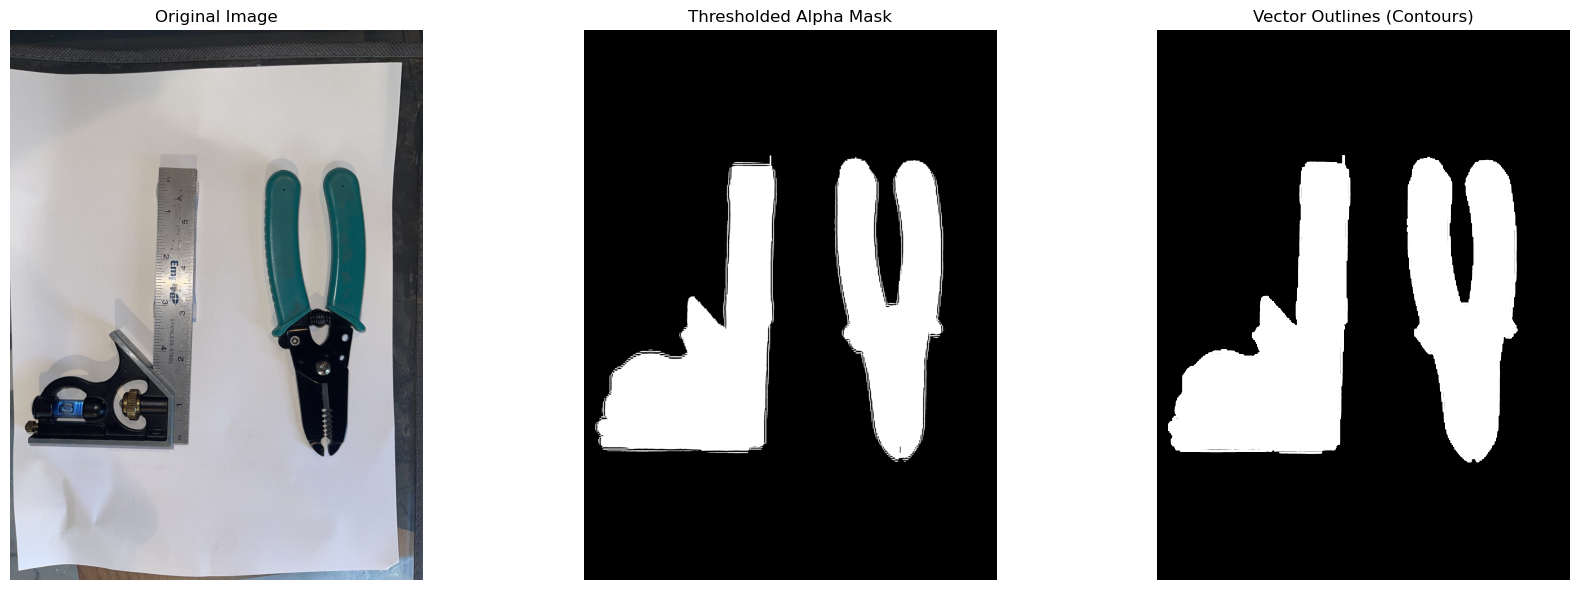

In [20]:
image_processs_pipeline('test/images/test10.jpg')

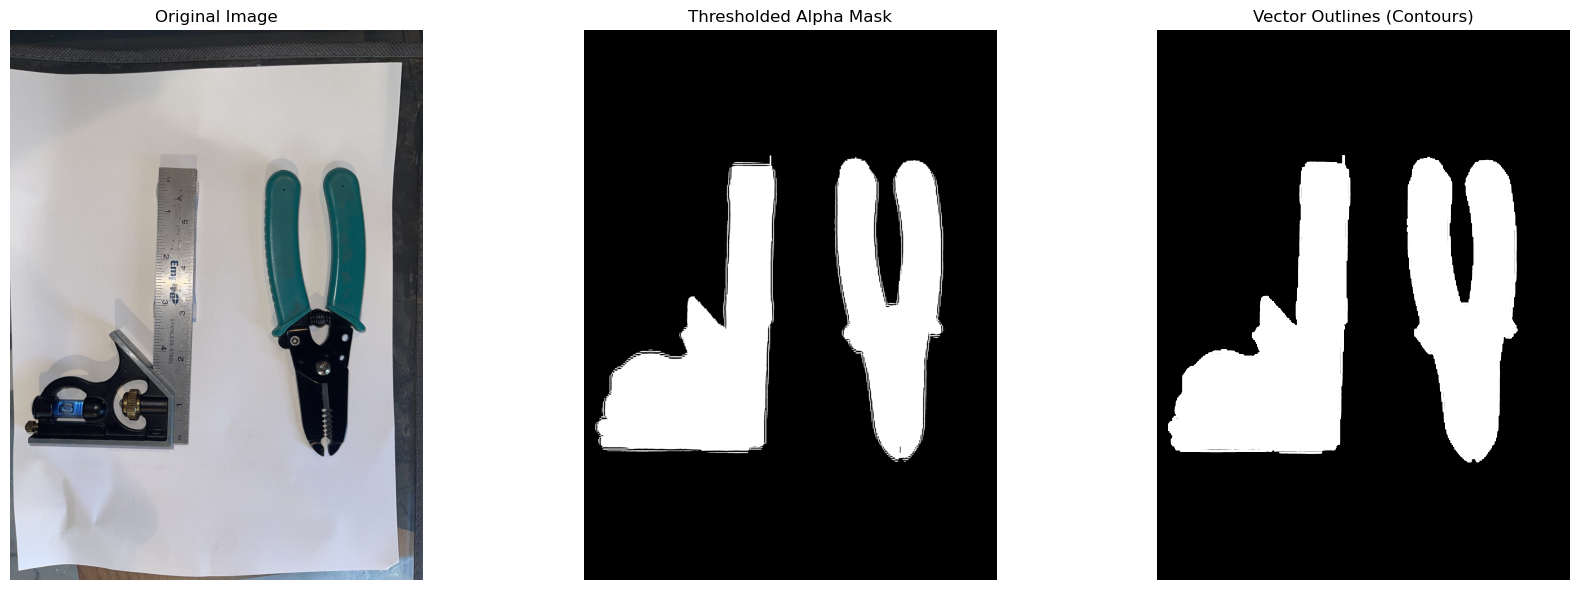

In [21]:
image_processs_pipeline('test/images/test9.jpg')

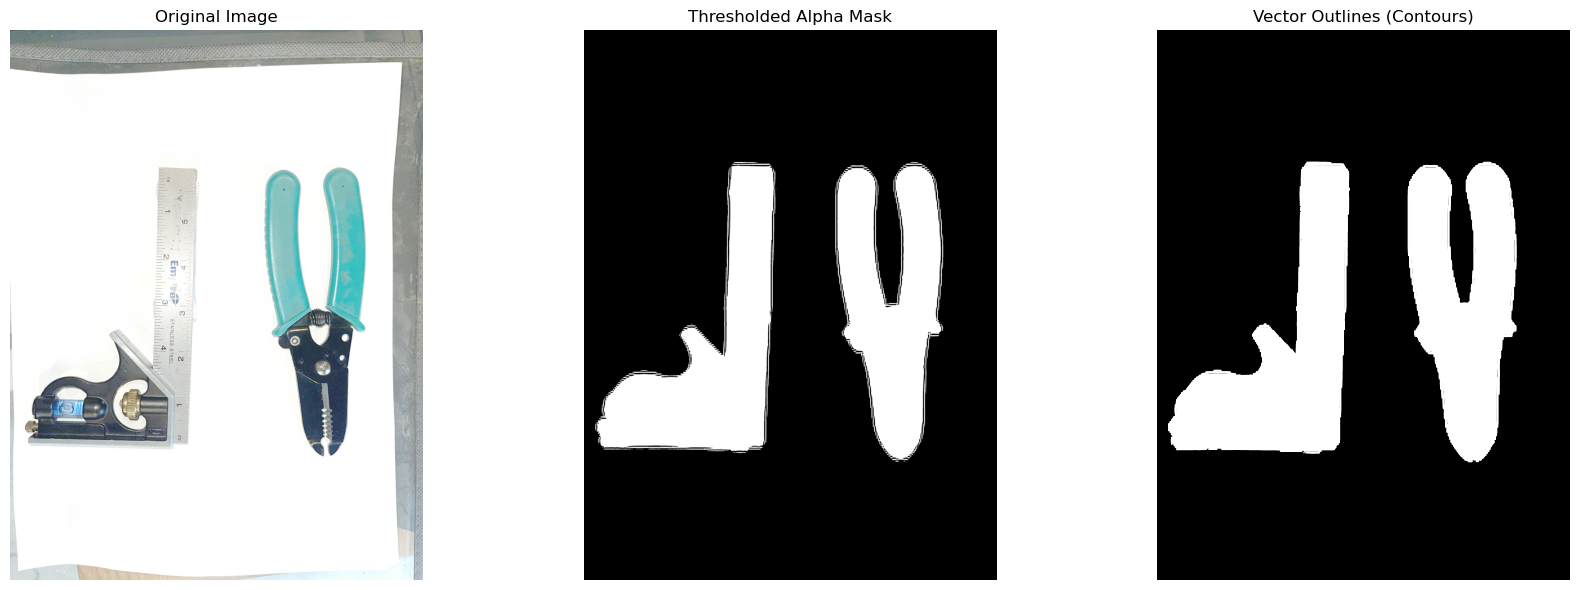

In [13]:
image_processs_pipeline('test/images/test10_2.jpg')

🔄 Starting complete image-to-vector workflow...
📷 Step 1: Removing background...
✅ Background removal complete
🎭 Step 2: Creating binary mask and extracting contours...
✅ Found 37 contours
💾 Step 3: Saving intermediate results...
Background-removed image saved to: output\no_background.png
Binary mask saved to: output\binary_mask.png
🎨 Step 4: Converting to smoothed vector...
Smoothed vector saved to: output\test4_vector.svg
✅ Vector conversion complete
📊 Step 5: Visualizing results...


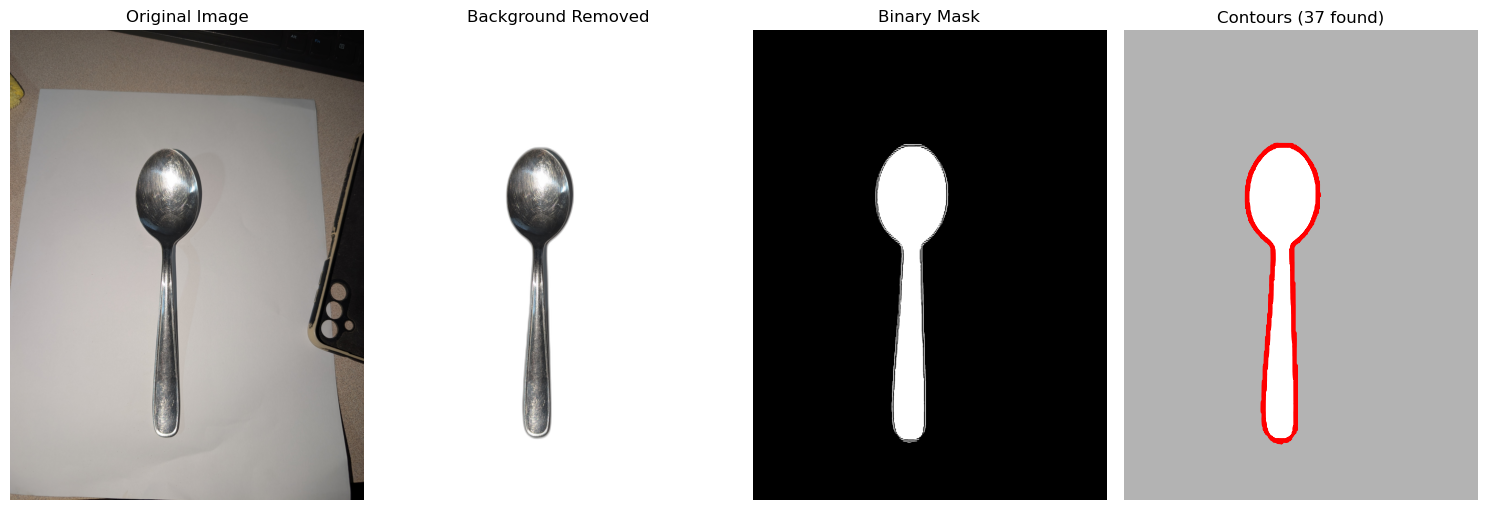

🎉 Workflow complete!


In [26]:
# Complete Image to Vector Workflow
# Background removal
from rembg import remove
# Image handling
from PIL import Image
# Bitmask and image processing
import numpy as np
from skimage import measure, filters
from skimage.io import imread, imsave
# Visualization
import matplotlib.pyplot as plt
# File handling
import io
import os
import tempfile
# Vectorization
import vtracer
from svgpathtools import svg2paths
from scipy.interpolate import splprep, splev
import svgwrite

def remove_background(input_path):
    """
    Remove background from an image using rembg
    
    Args:
        input_path (str): Path to input image
        
    Returns:
        tuple: (original_img, no_bg_img) - Original and background-removed PIL Images
    """
    # Load input image and convert to RGBA
    img = Image.open(input_path).convert('RGBA')
    
    # Convert to bytes for rembg processing
    img_bytes = io.BytesIO()
    img.save(img_bytes, format='PNG')
    img_bytes = img_bytes.getvalue()
    
    # Remove background
    output_bytes = remove(img_bytes)
    output_img = Image.open(io.BytesIO(output_bytes)).convert('RGBA')
    
    return img, output_img

def create_bitmask_and_contours(rgba_image):
    """
    Create binary mask from RGBA image and extract contours
    
    Args:
        rgba_image (PIL.Image): RGBA image with transparent background
        
    Returns:
        tuple: (binary_mask, contours)
            - binary_mask (numpy.ndarray): Boolean array where True = foreground
            - contours (list): List of contour arrays from skimage.measure.find_contours
    """
    # Extract alpha channel and create binary mask
    alpha = np.array(rgba_image.split()[-1])  # extract alpha channel
    binary_mask = alpha > 0  # threshold: foreground = True, background = False
    
    # Extract contours at the True/False boundary
    contours = measure.find_contours(binary_mask, level=0.5)
    
    return binary_mask, contours

def convert_to_smoothed_vector(input_image, output_svg, canvas_size=(500, 500), 
                             num_sampled_points=50, output_points=40, smoothing=1):
    """
    Convert an image to a smoothed vector SVG.
    
    Args:
        input_image (str or PIL.Image): Path to input image file or PIL Image object
        output_svg (str): Path for output SVG file
        canvas_size (tuple): Canvas size in pixels (width, height)
        num_sampled_points (int): Number of points to sample from original path
        output_points (int): Number of points in smoothed output
        smoothing (float): Smoothing parameter for spline (lower = tighter fit)
    """
    
    # Step 1: Handle input - either path or PIL Image
    if isinstance(input_image, str):
        img = Image.open(input_image)
    else:
        img = input_image
    
    img_array = np.array(img)
    
    # Invert colors
    if img_array.dtype == np.uint8:
        inverted_array = 255 - img_array
    else:
        inverted_array = np.iinfo(img_array.dtype).max - img_array
    
    inverted_img = Image.fromarray(inverted_array)
    
    # Save inverted image to temp file
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as temp_png:
        temp_png_path = temp_png.name
        inverted_img.save(temp_png_path)
    
    # Create intermediate SVG
    with tempfile.NamedTemporaryFile(suffix='.svg', delete=False) as temp_svg:
        temp_svg_path = temp_svg.name
    
    try:
        # Convert to SVG
        vtracer.convert_image_to_svg_py(temp_png_path, temp_svg_path, colormode='binary')
        
        # Step 2: Smooth the vector
        # Load SVG paths
        paths, *_ = svg2paths(temp_svg_path)
        
        if not paths:
            raise ValueError("No paths found in the generated SVG")
        
        # Use the first path
        path = paths[0]
        
        # Sample points from the path
        points = np.array([path.point(t) for t in np.linspace(0, 1, num_sampled_points)])
        x = points.real
        y = points.imag
        
        # Smooth with spline
        tck, _ = splprep([x, y], s=smoothing)
        u_new = np.linspace(0, 1, output_points)
        x_smooth, y_smooth = splev(u_new, tck)
        smooth_points = np.column_stack((x_smooth, y_smooth))
        
        # Compute bounding box and center on canvas
        min_x, min_y = np.min(smooth_points, axis=0)
        max_x, max_y = np.max(smooth_points, axis=0)
        path_width = max_x - min_x
        path_height = max_y - min_y
        
        canvas_width, canvas_height = canvas_size
        translate_x = (canvas_width - path_width) / 2 - min_x
        translate_y = (canvas_height - path_height) / 2 - min_y
        
        smooth_points_centered = [(x + translate_x, y + translate_y) for x, y in smooth_points]
        
        # Construct path string with closed path
        d_str = f"M {smooth_points_centered[0][0]},{smooth_points_centered[0][1]} " + \
                " ".join(f"L {x},{y}" for x, y in smooth_points_centered[1:]) + " Z"
        
        # Create final SVG
        dwg = svgwrite.Drawing(output_svg, size=canvas_size)
        dwg.add(dwg.path(d=d_str, fill="black", stroke="none"))
        dwg.save()
        
        print(f"Smoothed vector saved to: {output_svg}")
        
    finally:
        # Cleanup temp files
        os.unlink(temp_png_path)
        if os.path.exists(temp_svg_path):
            os.unlink(temp_svg_path)

def visualize_results(original_img, binary_mask, contours, no_bg_img=None):
    """
    Visualize the processing results
    
    Args:
        original_img (PIL.Image): Original image
        binary_mask (numpy.ndarray): Binary mask
        contours (list): List of contours
        no_bg_img (PIL.Image, optional): Background-removed image
    """
    # Determine number of subplots
    num_plots = 4 if no_bg_img is not None else 3
    
    fig, axes = plt.subplots(1, num_plots, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    plot_idx = 1
    
    # Background removed image (if provided)
    if no_bg_img is not None:
        axes[plot_idx].imshow(no_bg_img)
        axes[plot_idx].set_title('Background Removed')
        axes[plot_idx].axis('off')
        plot_idx += 1
    
    # Binary mask
    axes[plot_idx].imshow(binary_mask, cmap='gray')
    axes[plot_idx].set_title('Binary Mask')
    axes[plot_idx].axis('off')
    plot_idx += 1
    
    # Contours
    axes[plot_idx].imshow(binary_mask, cmap='gray', alpha=0.3)
    for contour in contours:
        axes[plot_idx].plot(contour[:, 1], contour[:, 0], 'r-', linewidth=2)
    axes[plot_idx].set_title(f'Contours ({len(contours)} found)')
    axes[plot_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

def save_intermediate_results(no_bg_img, binary_mask, output_dir='output'):
    """
    Save intermediate processing results
    
    Args:
        no_bg_img (PIL.Image): Background-removed image
        binary_mask (numpy.ndarray): Binary mask
        output_dir (str): Directory to save results
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Save background-removed image
    no_bg_path = os.path.join(output_dir, 'no_background.png')
    no_bg_img.save(no_bg_path)
    print(f"Background-removed image saved to: {no_bg_path}")
    
    # Save binary mask
    mask_path = os.path.join(output_dir, 'binary_mask.png')
    mask_img = Image.fromarray((binary_mask * 255).astype(np.uint8))
    mask_img.save(mask_path)
    print(f"Binary mask saved to: {mask_path}")
    
    return no_bg_path, mask_path

def complete_image_to_vector_workflow(input_path, output_svg=None, output_dir='output',
                                    canvas_size=(500, 500), num_sampled_points=50, 
                                    output_points=40, smoothing=1, visualize=True,
                                    save_intermediates=True):
    """
    Complete workflow: image -> background removal -> vectorization -> smoothing
    
    Args:
        input_path (str): Path to input image
        output_svg (str, optional): Path for output SVG. If None, uses input filename
        output_dir (str): Directory for output files
        canvas_size (tuple): Canvas size for final SVG
        num_sampled_points (int): Points to sample from vector path
        output_points (int): Points in smoothed output
        smoothing (float): Smoothing parameter
        visualize (bool): Whether to show visualization
        save_intermediates (bool): Whether to save intermediate results
        
    Returns:
        dict: Dictionary containing all results
    """
    
    print("🔄 Starting complete image-to-vector workflow...")
    
    # Step 1: Remove background
    print("📷 Step 1: Removing background...")
    original_img, no_bg_img = remove_background(input_path)
    print("✅ Background removal complete")
    
    # Step 2: Create bitmask and extract contours
    print("🎭 Step 2: Creating binary mask and extracting contours...")
    binary_mask, contours = create_bitmask_and_contours(no_bg_img)
    print(f"✅ Found {len(contours)} contours")
    
    # Step 3: Save intermediate results (optional)
    no_bg_path, mask_path = None, None
    if save_intermediates:
        print("💾 Step 3: Saving intermediate results...")
        no_bg_path, mask_path = save_intermediate_results(no_bg_img, binary_mask, output_dir)
    
    # Step 4: Convert to smoothed vector
    print("🎨 Step 4: Converting to smoothed vector...")
    if output_svg is None:
        base_name = os.path.splitext(os.path.basename(input_path))[0]
        output_svg = os.path.join(output_dir, f"{base_name}_vector.svg")
    
    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_svg), exist_ok=True)
    
    convert_to_smoothed_vector(
        no_bg_img, output_svg, canvas_size, 
        num_sampled_points, output_points, smoothing
    )
    print("✅ Vector conversion complete")
    
    # Step 5: Visualize results (optional)
    if visualize:
        print("📊 Step 5: Visualizing results...")
        visualize_results(original_img, binary_mask, contours, no_bg_img)
    
    print("🎉 Workflow complete!")
    
    # Return all results
    return {
        'original_img': original_img,
        'no_bg_img': no_bg_img,
        'binary_mask': binary_mask,
        'contours': contours,
        'output_svg': output_svg,
        'no_bg_path': no_bg_path,
        'mask_path': mask_path
    }

# Complete workflow example
input_path = 'test/images/test4.jpg'

# Run the complete workflow
results = complete_image_to_vector_workflow(
    input_path=input_path,
    output_dir='output',
    canvas_size=(500, 500),
    num_sampled_points=50,
    output_points=40,
    smoothing=1,
    visualize=True,
    save_intermediates=True
)

# You can also run individual steps if needed:
# Step 1: Remove background
# original_img, no_bg_img = remove_background(input_path)

# Step 2: Create bitmask and extract contours
# binary_mask, contours = create_bitmask_and_contours(no_bg_img)

# Step 3: Vectorize and smooth
# convert_to_smoothed_vector(no_bg_img, 'output/vector.svg')

# Step 4: Visualize results
# visualize_results(original_img, binary_mask, contours, no_bg_img)

🔄 Starting complete image-to-vector workflow...
📷 Step 1: Removing background...
✅ Background removal complete
🎭 Step 2: Creating binary mask and extracting contours...
✅ Found 1 contours
💾 Step 3: Saving intermediate results...
Background-removed image saved to: output\no_background.png
Binary mask saved to: output\binary_mask.png
🎨 Step 4: Converting to smoothed vector...
Smoothed vector saved to: output\test4_vector.svg
✅ Vector conversion complete
📊 Step 5: Visualizing results...


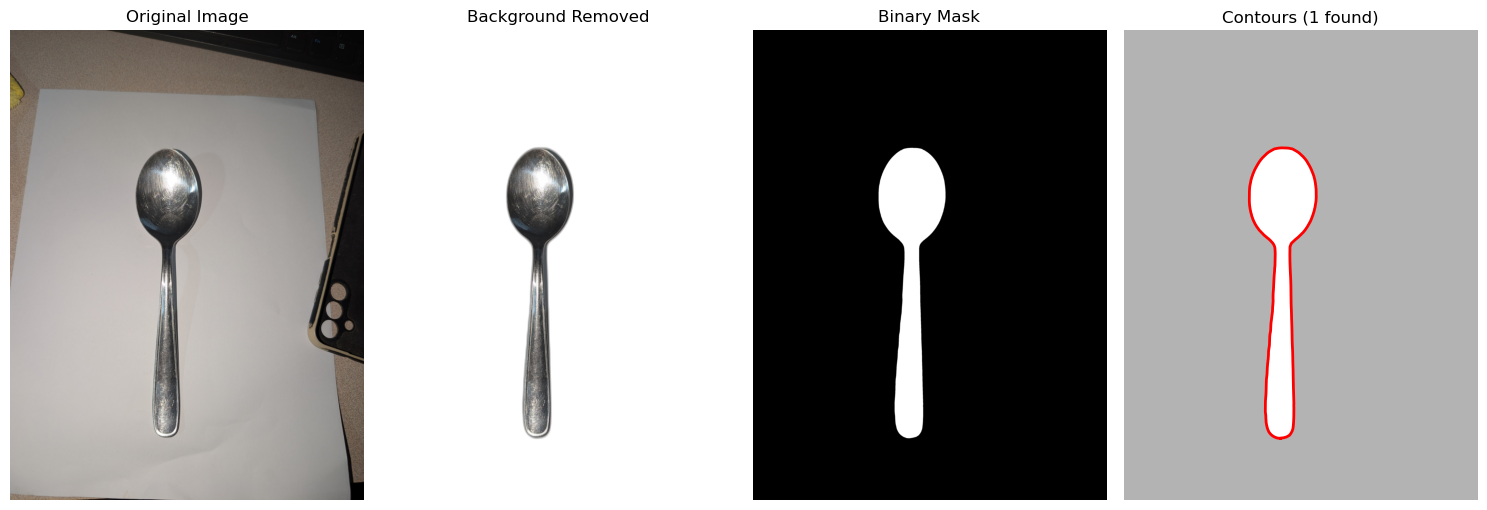

🎉 Workflow complete!


In [57]:
# Complete Image to Vector Workflow
# Background removal
from rembg import remove
# Image handling
from PIL import Image
# Bitmask and image processing
import numpy as np
from skimage import measure,morphology, filters
from skimage.io import imread, imsave
from scipy import ndimage
# Visualization
import matplotlib.pyplot as plt
# File handling
import io
import os
import tempfile
# Vectorization
import vtracer
from svgpathtools import svg2paths
from scipy.interpolate import splprep, splev
import svgwrite
 

def remove_background(input_path):
    """
    Remove background from an image using rembg
    
    Args:
        input_path (str): Path to input image
        
    Returns:
        tuple: (original_img, no_bg_img) - Original and background-removed PIL Images
    """
    # Load input image and convert to RGBA
    img = Image.open(input_path).convert('RGBA')
    
    # Convert to bytes for rembg processing
    img_bytes = io.BytesIO()
    img.save(img_bytes, format='PNG')
    img_bytes = img_bytes.getvalue()
    
    # Remove background
    output_bytes = remove(img_bytes)
    output_img = Image.open(io.BytesIO(output_bytes)).convert('RGBA')
    
    return img, output_img

# def create_bitmask_and_contours(rgba_image):
#     """
#     Create binary mask from RGBA image and extract contours
    
#     Args:
#         rgba_image (PIL.Image): RGBA image with transparent background
        
#     Returns:
#         tuple: (binary_mask, contours)
#             - binary_mask (numpy.ndarray): Boolean array where True = foreground
#             - contours (list): List of contour arrays from skimage.measure.find_contours
#     """
#     # Extract alpha channel and create binary mask
#     alpha = np.array(rgba_image.split()[-1])  # extract alpha channel
#     binary_mask = alpha > 0.3  # threshold: foreground = True, background = False
    
#     # Extract contours at the True/False boundary
#     contours = measure.find_contours(binary_mask, level=0.5)
    
#     return binary_mask, contours



import numpy as np
from PIL import Image
from skimage import measure, morphology, filters
from scipy import ndimage

def create_bitmask_and_contours(rgba_image):
    """
    Create smoothed binary mask from RGBA image and extract contours
    
    Args:
        rgba_image (PIL.Image): RGBA image with transparent background
        
    Returns:
        tuple: (binary_mask, contours)
            - binary_mask (numpy.ndarray): Boolean array where True = foreground
            - contours (list): List of smoothed contour arrays
    """
    # Extract alpha channel
    alpha = np.array(rgba_image.split()[-1])
    
    # Apply Gaussian blur for smooth edges
    alpha_smoothed = filters.gaussian(alpha, sigma=1.5)
    
    # Create binary mask with adaptive thresholding
    threshold = filters.threshold_otsu(alpha_smoothed)
    binary_mask = alpha_smoothed > threshold
    
    # Apply morphological operations for smooth, clean edges
    binary_mask = morphology.binary_closing(binary_mask, morphology.disk(2))
    binary_mask = morphology.binary_opening(binary_mask, morphology.disk(2))
    
    # Additional smoothing pass
    binary_mask = morphology.binary_erosion(binary_mask, morphology.disk(1))
    binary_mask = morphology.binary_dilation(binary_mask, morphology.disk(3))
    
    # Extract smooth contours
    contours = measure.find_contours(binary_mask.astype(float), level=0.5)
    
    # Apply contour smoothing
    smoothed_contours = []
    for contour in contours:
        if len(contour) > 10:
            smooth_contour = np.column_stack([
                ndimage.gaussian_filter1d(contour[:, 0], sigma=1.0),
                ndimage.gaussian_filter1d(contour[:, 1], sigma=1.0)
            ])
            smoothed_contours.append(smooth_contour)
        else:
            smoothed_contours.append(contour)
    
    return binary_mask, smoothed_contours

# Example usage:
# rgba_image = Image.open("output/no_background.png")
# binary_mask, contours = create_bitmask_and_contours(rgba_image)
def convert_to_smoothed_vector(input_image, output_svg, canvas_size=(500, 500), 
                             num_sampled_points=100, output_points=50, smoothing=1):
    """
    Convert an image to a smoothed vector SVG.
    
    Args:
        input_image (str or PIL.Image): Path to input image file or PIL Image object
        output_svg (str): Path for output SVG file
        canvas_size (tuple): Canvas size in pixels (width, height)
        num_sampled_points (int): Number of points to sample from original path
        output_points (int): Number of points in smoothed output
        smoothing (float): Smoothing parameter for spline (lower = tighter fit)
    """
    
    # Step 1: Handle input - either path or PIL Image
    if isinstance(input_image, str):
        img = Image.open(input_image)
    else:
        img = input_image
    
    img_array = np.array(img)
    
    # Invert colors
    if img_array.dtype == np.uint8:
        inverted_array = 255 - img_array
    else:
        inverted_array = np.iinfo(img_array.dtype).max - img_array
    
    inverted_img = Image.fromarray(inverted_array)
    
    # Save inverted image to temp file
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as temp_png:
        temp_png_path = temp_png.name
        inverted_img.save(temp_png_path)
    
    # Create intermediate SVG
    with tempfile.NamedTemporaryFile(suffix='.svg', delete=False) as temp_svg:
        temp_svg_path = temp_svg.name
    
    try:
        # Convert to SVG
        vtracer.convert_image_to_svg_py(temp_png_path, temp_svg_path, colormode='binary')
        
        # Step 2: Smooth the vector
        # Load SVG paths
        paths, *_ = svg2paths(temp_svg_path)
        
        if not paths:
            raise ValueError("No paths found in the generated SVG")
        
        # Use the first path
        path = paths[0]
        
        # Sample points from the path
        points = np.array([path.point(t) for t in np.linspace(0, 1, num_sampled_points)])
        x = points.real
        y = points.imag
        
        # Smooth with spline
        tck, _ = splprep([x, y], s=smoothing)
        u_new = np.linspace(0, 1, output_points)
        x_smooth, y_smooth = splev(u_new, tck)
        smooth_points = np.column_stack((x_smooth, y_smooth))
        
        # Compute bounding box and center on canvas
        min_x, min_y = np.min(smooth_points, axis=0)
        max_x, max_y = np.max(smooth_points, axis=0)
        path_width = max_x - min_x
        path_height = max_y - min_y
        
        canvas_width, canvas_height = canvas_size
        translate_x = (canvas_width - path_width) / 2 - min_x
        translate_y = (canvas_height - path_height) / 2 - min_y
        
        smooth_points_centered = [(x + translate_x, y + translate_y) for x, y in smooth_points]
        
        # Construct path string with closed path
        d_str = f"M {smooth_points_centered[0][0]},{smooth_points_centered[0][1]} " + \
                " ".join(f"L {x},{y}" for x, y in smooth_points_centered[1:]) + " Z"
        
        # Create final SVG
        dwg = svgwrite.Drawing(output_svg, size=canvas_size)
        dwg.add(dwg.path(d=d_str, fill="black", stroke="none"))
        dwg.save()
        
        print(f"Smoothed vector saved to: {output_svg}")
        
    finally:
        # Cleanup temp files
        os.unlink(temp_png_path)
        if os.path.exists(temp_svg_path):
            os.unlink(temp_svg_path)

def visualize_results(original_img, binary_mask, contours, no_bg_img=None):
    """
    Visualize the processing results
    
    Args:
        original_img (PIL.Image): Original image
        binary_mask (numpy.ndarray): Binary mask
        contours (list): List of contours
        no_bg_img (PIL.Image, optional): Background-removed image
    """
    # Determine number of subplots
    num_plots = 4 if no_bg_img is not None else 3
    
    fig, axes = plt.subplots(1, num_plots, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    plot_idx = 1
    
    # Background removed image (if provided)
    if no_bg_img is not None:
        axes[plot_idx].imshow(no_bg_img)
        axes[plot_idx].set_title('Background Removed')
        axes[plot_idx].axis('off')
        plot_idx += 1
    
    # Binary mask
    axes[plot_idx].imshow(binary_mask, cmap='gray')
    axes[plot_idx].set_title('Binary Mask')
    axes[plot_idx].axis('off')
    plot_idx += 1
    
    # Contours
    axes[plot_idx].imshow(binary_mask, cmap='gray', alpha=0.3)
    for contour in contours:
        axes[plot_idx].plot(contour[:, 1], contour[:, 0], 'r-', linewidth=2)
    axes[plot_idx].set_title(f'Contours ({len(contours)} found)')
    axes[plot_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

def save_intermediate_results(no_bg_img, binary_mask, output_dir='output'):
    """
    Save intermediate processing results
    
    Args:
        no_bg_img (PIL.Image): Background-removed image
        binary_mask (numpy.ndarray): Binary mask
        output_dir (str): Directory to save results
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Save background-removed image
    no_bg_path = os.path.join(output_dir, 'no_background.png')
    no_bg_img.save(no_bg_path)
    print(f"Background-removed image saved to: {no_bg_path}")
    
    # Save binary mask
    mask_path = os.path.join(output_dir, 'binary_mask.png')
    mask_img = Image.fromarray((binary_mask * 255).astype(np.uint8))
    mask_img.save(mask_path)
    print(f"Binary mask saved to: {mask_path}")
    
    return no_bg_path, mask_path

def complete_image_to_vector_workflow(input_path, output_svg=None, output_dir='output',
                                    canvas_size=(500, 500), num_sampled_points=50, 
                                    output_points=40, smoothing=1, visualize=True,
                                    save_intermediates=True):
    """
    Complete workflow: image -> background removal -> vectorization -> smoothing
    
    Args:
        input_path (str): Path to input image
        output_svg (str, optional): Path for output SVG. If None, uses input filename
        output_dir (str): Directory for output files
        canvas_size (tuple): Canvas size for final SVG
        num_sampled_points (int): Points to sample from vector path
        output_points (int): Points in smoothed output
        smoothing (float): Smoothing parameter
        visualize (bool): Whether to show visualization
        save_intermediates (bool): Whether to save intermediate results
        
    Returns:
        dict: Dictionary containing all results
    """
    
    print("🔄 Starting complete image-to-vector workflow...")
    
    # Step 1: Remove background
    print("📷 Step 1: Removing background...")
    original_img, no_bg_img = remove_background(input_path)
    print("✅ Background removal complete")
    
    # Step 2: Create bitmask and extract contours
    print("🎭 Step 2: Creating binary mask and extracting contours...")
    binary_mask, contours = create_bitmask_and_contours(no_bg_img)
    print(f"✅ Found {len(contours)} contours")
    
    # Step 3: Save intermediate results (optional)
    no_bg_path, mask_path = None, None
    if save_intermediates:
        print("💾 Step 3: Saving intermediate results...")
        no_bg_path, mask_path = save_intermediate_results(no_bg_img, binary_mask, output_dir)
    
    # Step 4: Convert to smoothed vector
    print("🎨 Step 4: Converting to smoothed vector...")
    if output_svg is None:
        base_name = os.path.splitext(os.path.basename(input_path))[0]
        output_svg = os.path.join(output_dir, f"{base_name}_vector.svg")
    
    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_svg), exist_ok=True)
    
    convert_to_smoothed_vector(
        mask_path, output_svg, canvas_size, 
        num_sampled_points, output_points, smoothing
    )
    print("✅ Vector conversion complete")
    
    # Step 5: Visualize results (optional)
    if visualize:
        print("📊 Step 5: Visualizing results...")
        visualize_results(original_img, binary_mask, contours, no_bg_img)
    
    print("🎉 Workflow complete!")
    
    # Return all results
    return {
        'original_img': original_img,
        'no_bg_img': no_bg_img,
        'binary_mask': binary_mask,
        'contours': contours,
        'output_svg': output_svg,
        'no_bg_path': no_bg_path,
        'mask_path': mask_path
    }

# Example usage:

# Complete workflow example
input_path = 'test/images/test4.jpg'
# input_path = 'test/images/test5.jpg'

with Image.open(input_path) as img: 
    canvas_size = img.size 
# Run the complete workflow
results = complete_image_to_vector_workflow(
    input_path=input_path,
    output_dir='output',
    canvas_size=canvas_size,
    num_sampled_points=50,
    output_points=40,
    smoothing=1,
    visualize=True,
    save_intermediates=True
)
    
# # You can also run individual steps if needed:
# # Step 1: Remove background
# original_img, no_bg_img = remove_background(input_path)

# # Step 2: Create bitmask and extract contours
# binary_mask, contours = create_bitmask_and_contours(no_bg_img)

# # Step 3: Vectorize and smooth
# convert_to_smoothed_vector(no_bg_img, 'output/vector.svg')

# # Step 4: Visualize results
# visualize_results(original_img, binary_mask, contours, no_bg_img)

=== Processing no_background.png ===
Loaded image: (3072, 4080) pixels, mode: RGBA
Processing image for edge detection...
Found 1 contours
Binary mask shape: (4080, 3072)
Foreground pixels: 695579


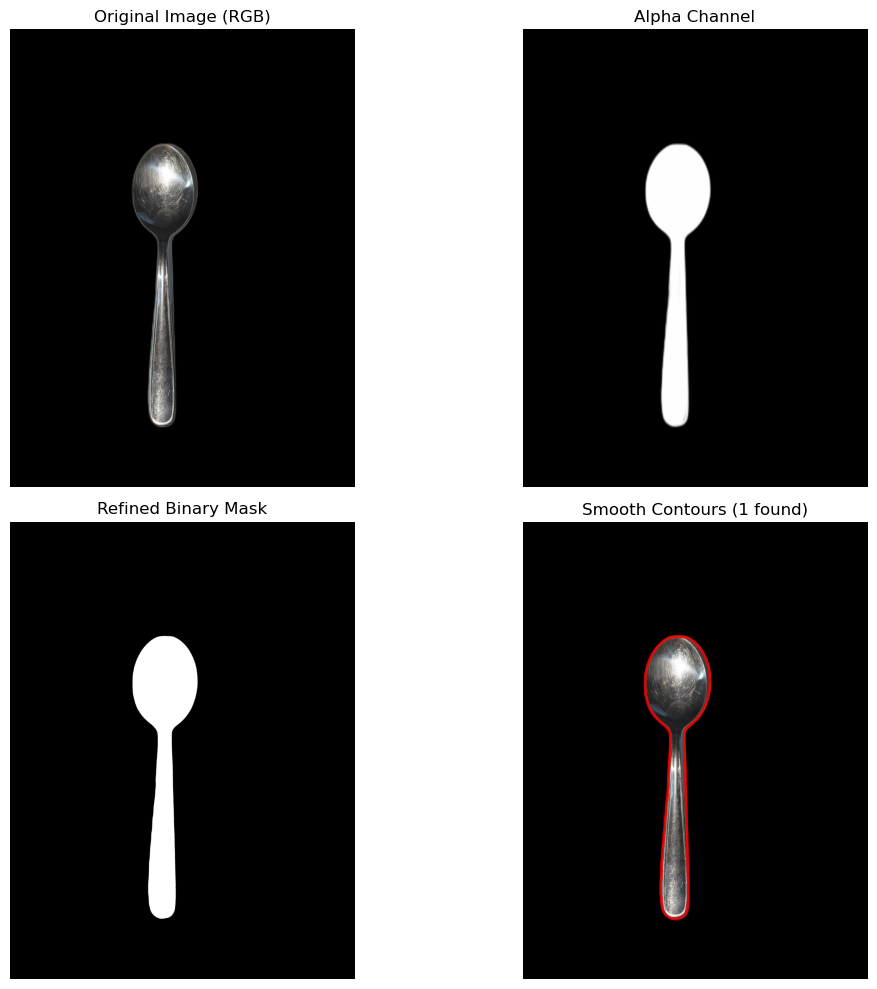

C:\Users\oran\AppData\Local\Temp\ipykernel_12732\3395928388.py:112: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_image = Image.fromarray((binary_mask * 255).astype(np.uint8), mode='L')


Saved refined mask to: output/refined_mask.png
Saved clean B&W version to: output/clean_black_white.png

=== Advanced Processing Examples ===


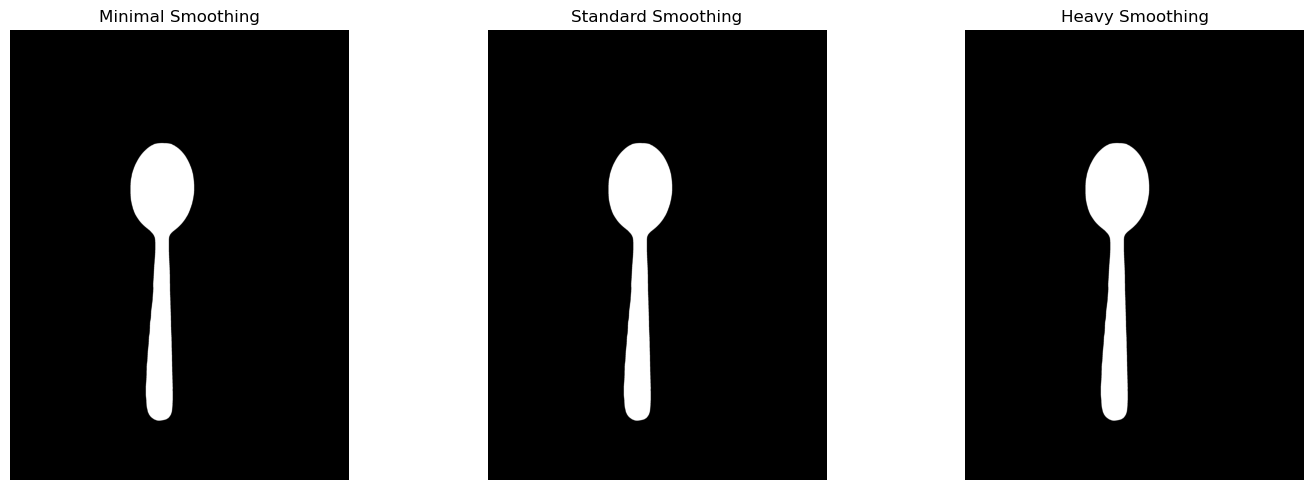


=== Results Summary ===
Files created:
- output/edge_detection_results.png (visualization)
- output/refined_mask.png (binary mask)
- output/clean_black_white.png (clean B&W version)
- output/smoothing_comparison.png (different smoothing levels)


In [38]:
import numpy as np
from PIL import Image
from skimage import measure, morphology, filters
from scipy import ndimage
import matplotlib.pyplot as plt
import os

def create_bitmask_and_contours(rgba_image):
    """
    Create binary mask from RGBA image and extract smooth contours
    
    Args:
        rgba_image (PIL.Image): RGBA image with transparent background
        
    Returns:
        tuple: (binary_mask, contours)
            - binary_mask (numpy.ndarray): Boolean array where True = foreground
            - contours (list): List of smoothed contour arrays
    """
    # Extract alpha channel
    alpha = np.array(rgba_image.split()[-1])
    
    # Apply Gaussian blur to smooth the alpha channel before thresholding
    alpha_smoothed = filters.gaussian(alpha, sigma=1.0)
    
    # Create binary mask with adaptive thresholding
    threshold = filters.threshold_otsu(alpha_smoothed)
    binary_mask = alpha_smoothed > threshold
    
    # Apply morphological operations to clean up the mask
    binary_mask = morphology.binary_closing(binary_mask, morphology.disk(2))
    binary_mask = morphology.binary_opening(binary_mask, morphology.disk(1))
    
    # Apply additional smoothing
    binary_mask = morphology.binary_erosion(binary_mask, morphology.disk(1))
    binary_mask = morphology.binary_dilation(binary_mask, morphology.disk(2))
    
    # Extract contours with sub-pixel precision
    contours = measure.find_contours(binary_mask.astype(float), level=0.5)
    
    # Smooth the contours
    smoothed_contours = []
    for contour in contours:
        if len(contour) > 10:
            smooth_contour = np.column_stack([
                ndimage.gaussian_filter1d(contour[:, 0], sigma=0.8),
                ndimage.gaussian_filter1d(contour[:, 1], sigma=0.8)
            ])
            smoothed_contours.append(smooth_contour)
        else:
            smoothed_contours.append(contour)
    
    return binary_mask, smoothed_contours

def process_no_background_image():
    """
    Complete example for processing 'output/no_background.png'
    """
    # Load the RGBA image
    # image_path = "output/no_background.png"
    image_path = "test/images/test5.jpg"
    try:
        # Load image
        rgba_image = Image.open(image_path)
        print(f"Loaded image: {rgba_image.size} pixels, mode: {rgba_image.mode}")
        
        # Convert to RGBA if not already
        if rgba_image.mode != 'RGBA':
            rgba_image = rgba_image.convert('RGBA')
            print("Converted image to RGBA mode")
        
        # Process the image
        print("Processing image for edge detection...")
        binary_mask, contours = create_bitmask_and_contours(rgba_image)
        
        print(f"Found {len(contours)} contours")
        print(f"Binary mask shape: {binary_mask.shape}")
        print(f"Foreground pixels: {np.sum(binary_mask)}")
        
        # Create visualization
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Original image (RGB channels only)
        rgb_image = np.array(rgba_image)[:, :, :3]
        axes[0, 0].imshow(rgb_image)
        axes[0, 0].set_title("Original Image (RGB)")
        axes[0, 0].axis('off')
        
        # Alpha channel
        alpha_channel = np.array(rgba_image.split()[-1])
        axes[0, 1].imshow(alpha_channel, cmap='gray')
        axes[0, 1].set_title("Alpha Channel")
        axes[0, 1].axis('off')
        
        # Binary mask
        axes[1, 0].imshow(binary_mask, cmap='gray')
        axes[1, 0].set_title("Refined Binary Mask")
        axes[1, 0].axis('off')
        
        # Contours overlay
        axes[1, 1].imshow(rgb_image)
        for i, contour in enumerate(contours):
            axes[1, 1].plot(contour[:, 1], contour[:, 0], 'r-', linewidth=2, alpha=0.8)
        axes[1, 1].set_title(f"Smooth Contours ({len(contours)} found)")
        axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.savefig("output/edge_detection_results.png", dpi=150, bbox_inches='tight')
        plt.show()
        
        # Save the refined binary mask
        mask_image = Image.fromarray((binary_mask * 255).astype(np.uint8), mode='L')
        mask_image.save("output/refined_mask.png")
        print("Saved refined mask to: output/refined_mask.png")
        
        # Create a clean black and white version
        # White foreground, black background
        bw_array = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
        bw_array[binary_mask] = [255, 255, 255]  # White foreground
        bw_array[~binary_mask] = [0, 0, 0]       # Black background
        
        bw_image = Image.fromarray(bw_array)
        bw_image.save("output/clean_black_white.png")
        print("Saved clean B&W version to: output/clean_black_white.png")
        
        return binary_mask, contours
        
    except FileNotFoundError:
        print(f"Error: Could not find image at {image_path}")
        print("Please make sure the file exists and the path is correct.")
        return None, None
    except Exception as e:
        print(f"Error processing image: {str(e)}")
        return None, None

def advanced_processing_example():
    """
    Example with different smoothing levels
    """
    image_path = "output/no_background.png"
    
    try:
        rgba_image = Image.open(image_path)
        if rgba_image.mode != 'RGBA':
            rgba_image = rgba_image.convert('RGBA')
        
        # Test different smoothing levels
        smoothing_levels = {
            'minimal': {'blur_sigma': 0.5, 'morph_size': 1},
            'standard': {'blur_sigma': 1.0, 'morph_size': 2},
            'heavy': {'blur_sigma': 2.0, 'morph_size': 3}
        }
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        for i, (level_name, params) in enumerate(smoothing_levels.items()):
            # Custom processing with different parameters
            alpha = np.array(rgba_image.split()[-1])
            alpha_smoothed = filters.gaussian(alpha, sigma=params['blur_sigma'])
            threshold = filters.threshold_otsu(alpha_smoothed)
            binary_mask = alpha_smoothed > threshold
            
            # Apply morphological operations
            selem = morphology.disk(params['morph_size'])
            binary_mask = morphology.binary_closing(binary_mask, selem)
            binary_mask = morphology.binary_opening(binary_mask, selem)
            
            # Display result
            axes[i].imshow(binary_mask, cmap='gray')
            axes[i].set_title(f"{level_name.title()} Smoothing")
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.savefig("output/smoothing_comparison.png", dpi=150, bbox_inches='tight')
        plt.show()
        
    except Exception as e:
        print(f"Error in advanced processing: {str(e)}")

# Main execution
if __name__ == "__main__":
    # Create output directory if it doesn't exist
    os.makedirs("output", exist_ok=True)
    
    print("=== Processing no_background.png ===")
    binary_mask, contours = process_no_background_image()
    
    if binary_mask is not None:
        print("\n=== Advanced Processing Examples ===")
        advanced_processing_example()
        
        print("\n=== Results Summary ===")
        print("Files created:")
        print("- output/edge_detection_results.png (visualization)")
        print("- output/refined_mask.png (binary mask)")
        print("- output/clean_black_white.png (clean B&W version)")
        print("- output/smoothing_comparison.png (different smoothing levels)")

=== Processing no_background.png ===
Loaded image: (3072, 4080) pixels, mode: RGBA
Processing image for edge detection...
Found 1 contours
Binary mask shape: (4080, 3072)
Foreground pixels: 2019366


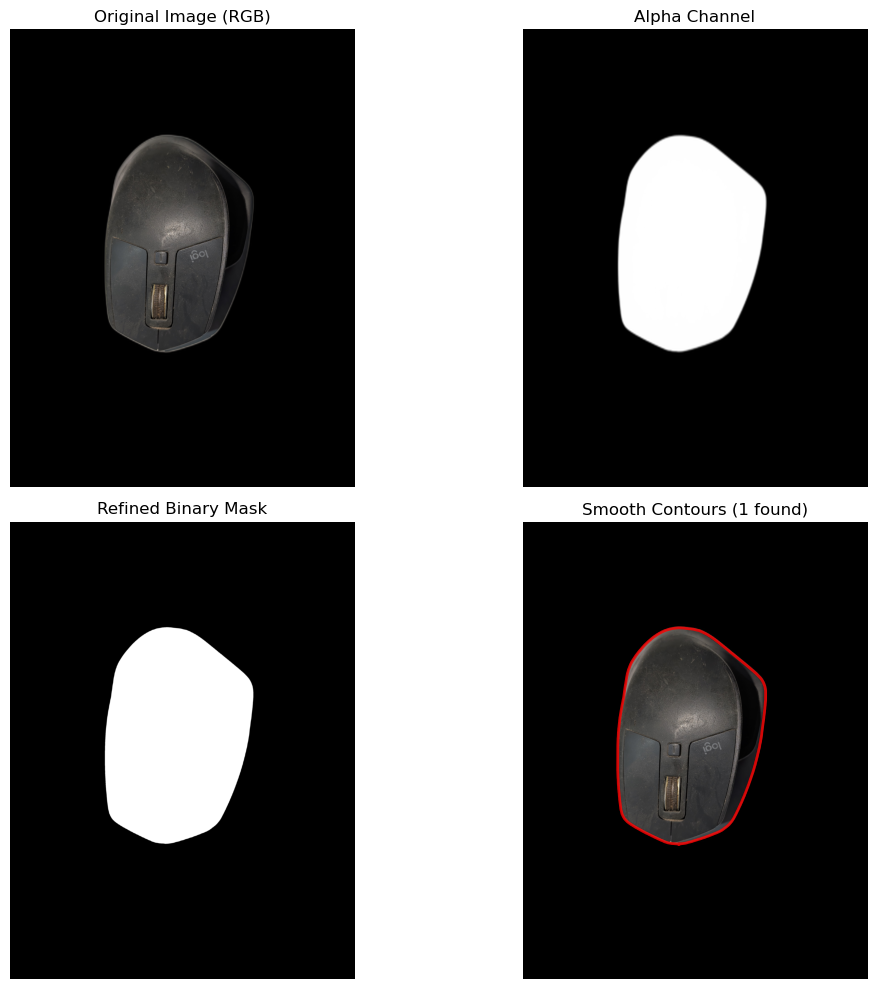

C:\Users\oran\AppData\Local\Temp\ipykernel_12732\1749491484.py:112: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_image = Image.fromarray((binary_mask * 255).astype(np.uint8), mode='L')


Saved refined mask to: output/refined_mask.png
Saved clean B&W version to: output/clean_black_white.png

=== Advanced Processing Examples ===


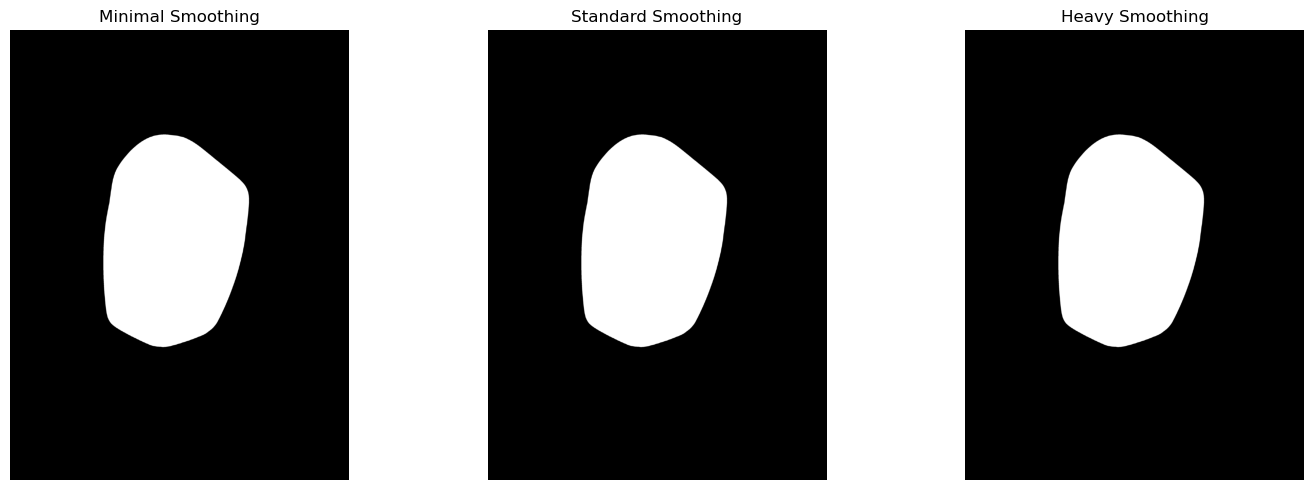


=== Results Summary ===
Files created:
- output/edge_detection_results.png (visualization)
- output/refined_mask.png (binary mask)
- output/clean_black_white.png (clean B&W version)
- output/smoothing_comparison.png (different smoothing levels)


In [41]:
import numpy as np
from PIL import Image
from skimage import measure, morphology, filters
from scipy import ndimage
import matplotlib.pyplot as plt
import os

def create_bitmask_and_contours(rgba_image):
    """
    Create binary mask from RGBA image and extract smooth contours
    
    Args:
        rgba_image (PIL.Image): RGBA image with transparent background
        
    Returns:
        tuple: (binary_mask, contours)
            - binary_mask (numpy.ndarray): Boolean array where True = foreground
            - contours (list): List of smoothed contour arrays
    """
    # Extract alpha channel
    alpha = np.array(rgba_image.split()[-1])
    
    # Apply Gaussian blur to smooth the alpha channel before thresholding
    alpha_smoothed = filters.gaussian(alpha, sigma=1.0)
    
    # Create binary mask with adaptive thresholding
    threshold = filters.threshold_otsu(alpha_smoothed)
    binary_mask = alpha_smoothed > threshold
    
    # Apply morphological operations to clean up the mask
    binary_mask = morphology.binary_closing(binary_mask, morphology.disk(2))
    binary_mask = morphology.binary_opening(binary_mask, morphology.disk(1))
    
    # Apply additional smoothing
    binary_mask = morphology.binary_erosion(binary_mask, morphology.disk(1))
    binary_mask = morphology.binary_dilation(binary_mask, morphology.disk(2))
    
    # Extract contours with sub-pixel precision
    contours = measure.find_contours(binary_mask.astype(float), level=0.5)
    
    # Smooth the contours
    smoothed_contours = []
    for contour in contours:
        if len(contour) > 10:
            smooth_contour = np.column_stack([
                ndimage.gaussian_filter1d(contour[:, 0], sigma=0.8),
                ndimage.gaussian_filter1d(contour[:, 1], sigma=0.8)
            ])
            smoothed_contours.append(smooth_contour)
        else:
            smoothed_contours.append(contour)
    
    return binary_mask, smoothed_contours

def process_no_background_image():
    """
    Complete example for processing 'output/no_background.png'
    """
    # Load the RGBA image
    image_path = "output/no_background.png"
    # image_path = "test/images/test5.jpg"
    try:
        # Load image
        rgba_image = Image.open(image_path)
        print(f"Loaded image: {rgba_image.size} pixels, mode: {rgba_image.mode}")
        
        # Convert to RGBA if not already
        if rgba_image.mode != 'RGBA':
            rgba_image = rgba_image.convert('RGBA')
            print("Converted image to RGBA mode")
        
        # Process the image
        print("Processing image for edge detection...")
        binary_mask, contours = create_bitmask_and_contours(rgba_image)
        
        print(f"Found {len(contours)} contours")
        print(f"Binary mask shape: {binary_mask.shape}")
        print(f"Foreground pixels: {np.sum(binary_mask)}")
        
        # Create visualization
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Original image (RGB channels only)
        rgb_image = np.array(rgba_image)[:, :, :3]
        axes[0, 0].imshow(rgb_image)
        axes[0, 0].set_title("Original Image (RGB)")
        axes[0, 0].axis('off')
        
        # Alpha channel
        alpha_channel = np.array(rgba_image.split()[-1])
        axes[0, 1].imshow(alpha_channel, cmap='gray')
        axes[0, 1].set_title("Alpha Channel")
        axes[0, 1].axis('off')
        
        # Binary mask
        axes[1, 0].imshow(binary_mask, cmap='gray')
        axes[1, 0].set_title("Refined Binary Mask")
        axes[1, 0].axis('off')
        
        # Contours overlay
        axes[1, 1].imshow(rgb_image)
        for i, contour in enumerate(contours):
            axes[1, 1].plot(contour[:, 1], contour[:, 0], 'r-', linewidth=2, alpha=0.8)
        axes[1, 1].set_title(f"Smooth Contours ({len(contours)} found)")
        axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.savefig("output/edge_detection_results.png", dpi=150, bbox_inches='tight')
        plt.show()
        
        # Save the refined binary mask
        mask_image = Image.fromarray((binary_mask * 255).astype(np.uint8), mode='L')
        mask_image.save("output/refined_mask.png")
        print("Saved refined mask to: output/refined_mask.png")
        
        # Create a clean black and white version
        # White foreground, black background
        bw_array = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
        bw_array[binary_mask] = [255, 255, 255]  # White foreground
        bw_array[~binary_mask] = [0, 0, 0]       # Black background
        
        bw_image = Image.fromarray(bw_array)
        bw_image.save("output/clean_black_white.png")
        print("Saved clean B&W version to: output/clean_black_white.png")
        
        return binary_mask, contours
        
    except FileNotFoundError:
        print(f"Error: Could not find image at {image_path}")
        print("Please make sure the file exists and the path is correct.")
        return None, None
    except Exception as e:
        print(f"Error processing image: {str(e)}")
        return None, None

def advanced_processing_example():
    """
    Example with different smoothing levels
    """
    image_path = "output/no_background.png"
    
    try:
        rgba_image = Image.open(image_path)
        if rgba_image.mode != 'RGBA':
            rgba_image = rgba_image.convert('RGBA')
        
        # Test different smoothing levels
        smoothing_levels = {
            'minimal': {'blur_sigma': 0.5, 'morph_size': 1},
            'standard': {'blur_sigma': 1.0, 'morph_size': 2},
            'heavy': {'blur_sigma': 2.0, 'morph_size': 3}
        }
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        for i, (level_name, params) in enumerate(smoothing_levels.items()):
            # Custom processing with different parameters
            alpha = np.array(rgba_image.split()[-1])
            alpha_smoothed = filters.gaussian(alpha, sigma=params['blur_sigma'])
            threshold = filters.threshold_otsu(alpha_smoothed)
            binary_mask = alpha_smoothed > threshold
            
            # Apply morphological operations
            selem = morphology.disk(params['morph_size'])
            binary_mask = morphology.binary_closing(binary_mask, selem)
            binary_mask = morphology.binary_opening(binary_mask, selem)
            
            # Display result
            axes[i].imshow(binary_mask, cmap='gray')
            axes[i].set_title(f"{level_name.title()} Smoothing")
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.savefig("output/smoothing_comparison.png", dpi=150, bbox_inches='tight')
        plt.show()
        
    except Exception as e:
        print(f"Error in advanced processing: {str(e)}")

# Main execution
if __name__ == "__main__":
    # Create output directory if it doesn't exist
    os.makedirs("output", exist_ok=True)
    
    print("=== Processing no_background.png ===")
    binary_mask, contours = process_no_background_image()
    
    if binary_mask is not None:
        print("\n=== Advanced Processing Examples ===")
        advanced_processing_example()
        
        print("\n=== Results Summary ===")
        print("Files created:")
        print("- output/edge_detection_results.png (visualization)")
        print("- output/refined_mask.png (binary mask)")
        print("- output/clean_black_white.png (clean B&W version)")
        print("- output/smoothing_comparison.png (different smoothing levels)")

In [46]:
import numpy as np
from PIL import Image
from skimage import measure, morphology, filters
from scipy import ndimage

def create_bitmask_and_contours(rgba_image):
    """
    Create binary mask from RGBA image and extract smooth contours
    Uses standard smoothing by default for clean edges
    
    Args:
        rgba_image (PIL.Image): RGBA image with transparent background
        
    Returns:
        tuple: (binary_mask, contours)
            - binary_mask (numpy.ndarray): Boolean array where True = foreground
            - contours (list): List of smoothed contour arrays
    """
    # Extract alpha channel
    alpha = np.array(rgba_image.split()[-1])
    
    # Apply Gaussian blur to smooth the alpha channel
    alpha_smoothed = filters.gaussian(alpha, sigma=1.0)
    
    # Create binary mask with adaptive thresholding
    threshold = filters.threshold_otsu(alpha_smoothed)
    binary_mask = alpha_smoothed > threshold
    
    # Apply morphological operations to clean up edges and smooth
    binary_mask = morphology.binary_closing(binary_mask, morphology.disk(2))
    binary_mask = morphology.binary_opening(binary_mask, morphology.disk(1))
    
    # Additional smoothing with erosion and dilation
    binary_mask = morphology.binary_erosion(binary_mask, morphology.disk(1))
    binary_mask = morphology.binary_dilation(binary_mask, morphology.disk(2))
    
    # Extract contours with sub-pixel precision
    contours = measure.find_contours(binary_mask.astype(float), level=0.5)
    
    # Apply smoothing to contours
    smoothed_contours = []
    for contour in contours:
        if len(contour) > 10:  # Only smooth contours with enough points
            smooth_contour = np.column_stack([
                ndimage.gaussian_filter1d(contour[:, 0], sigma=0.8),
                ndimage.gaussian_filter1d(contour[:, 1], sigma=0.8)
            ])
            smoothed_contours.append(smooth_contour)
        else:
            smoothed_contours.append(contour)
    
    return binary_mask, smoothed_contours

# Example usage:
rgba_image = Image.open("output/no_background.png")
binary_mask, contours = create_bitmask_and_contours(rgba_image)

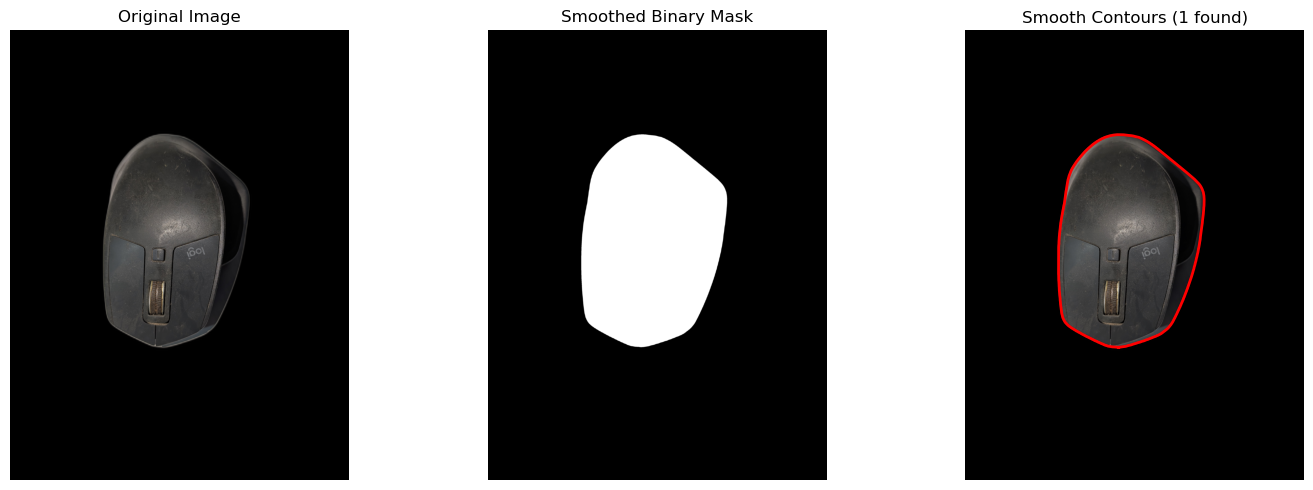

Processed image with 1 smooth contours
Binary mask shape: (4080, 3072)
Foreground pixels: 2019366


In [49]:
rgba_image = Image.open("output/no_background.png")
binary_mask, contours = create_bitmask_and_contours(rgba_image)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image (RGB only)
rgb_image = np.array(rgba_image)[:, :, :3]
axes[0].imshow(rgb_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Binary mask (black and white)
axes[1].imshow(binary_mask, cmap='gray')
axes[1].set_title("Smoothed Binary Mask")
axes[1].axis('off')

# Contours overlay on original
axes[2].imshow(rgb_image)
for contour in contours:
    axes[2].plot(contour[:, 1], contour[:, 0], 'red', linewidth=2)
axes[2].set_title(f"Smooth Contours ({len(contours)} found)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Processed image with {len(contours)} smooth contours")
print(f"Binary mask shape: {binary_mask.shape}")
print(f"Foreground pixels: {np.sum(binary_mask)}")